#### Mounting the drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
# !apt-get update -qq
# !apt-get install -y aria2

#### Downloading the dataset

RGB and VIS/NIR Hyperspectral Imaging Data for 90 Rice Seed Varieties

* Rice Varieties: 90 distinct rice seed species.
* Samples per Species: 96 individual kernels each — 8,640 kernels total.
* Imaging Systems Used:
    * VIS/NIR Hyperspectral Imaging (~385–1000 nm) using a Specim V10E spectrograph with a Hamamatsu ORCA-05G CCD camera.
    * RGB Photography with a Fujifilm X-M1 camera (35 mm lens).


In [ ]:
# !aria2c -x 16 -s 16 \
# "https://zenodo.org/records/3241923/files/RGB%20and%20VIS-NIR%20HSI%20Data%20for%2090%20Rice%20Seed%20Varieties.zip?download=1" \
# -o rice_hsi.zip

Verifying the downloaded dataset

In [ ]:
# !md5sum rice_hsi.zip

#### Installing dependencies

In [ ]:
!pip install spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 22.1 MB/s eta 0:00:00


### Imports

In [4]:
import os
import sys
import re
import math
import zipfile
import random
import shutil
from collections import defaultdict, Counter
from tqdm.auto import tqdm
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from skimage.filters import threshold_otsu, threshold_local
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, binary_closing, disk
from scipy.ndimage import binary_fill_holes
from skimage.segmentation import clear_border
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import spectral

ModuleNotFoundError: No module named 'spectral'

### Config

In [ ]:
spectral.settings.envi_support_nonlowercase_params = True
spectral.settings.warn_no_wavelength = False

torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()

In [5]:
CONFIG = {
    "dataset_path" :  "/content/drive/MyDrive/rice_hsi/",
    "base_path" : "/content/drive/MyDrive/rice_hsi/RGB and VIS-NIR HSI Data for 90 Rice Seed Varieties",
    "patches_dir": "/content/drive/MyDrive/rice_hsi_patches/",
    "output_dir": "/content/drive/MyDrive/rice_hsi_output/",
    "device" : torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "seed" : 42,
}

In [ ]:


# shutil.make_archive(
#     "rice_patches",
#     "zip",
#     CONFIG["patches_dir"]
# )


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])


Setup

In [ ]:
# zip_path = "rice_hsi.zip"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(zip_path.split('.')[0])

# print("Extraction complete.")


* HSI and RGB are NOT geometrically aligned.

They were captured by different sensors.

In [ ]:
# for root, dirs, files in os.walk(CONFIG["dataset_path"]):
#     print(f"root: {root}")
#     print(f"dirs: {dirs}")

#     for f in files[:5]:
#         print("     ", f)

### Dataset

* 90 rice varieties
* 96 kernels per variety
* 2 bundles per variety
* 48 seeds per bundle
* VIS–NIR hyperspectral cubes
* Corresponding RGB images
* Calibration artifacts (chessboard)

#### Dataset Census

In [ ]:
variety_counts = defaultdict(int)
cube_paths = []

for folder in os.listdir(CONFIG["base_path"]):
    if folder.startswith("Data-VIS"):
        folder_path = os.path.join(CONFIG["base_path"], folder)

        for f in os.listdir(folder_path):
            if f.endswith(".hdr") and f.lower() != "black.hdr":
                name = f.replace(".hdr", "")
                variety = re.sub(r'-\d+$', '', name)

                variety_counts[variety] += 1
                cube_paths.append(os.path.join(folder_path, f))

print("Total varieties:", len(variety_counts))
print("Total cubes:", len(cube_paths))


Total varieties: 90
Total cubes: 180


#### Wavelength Analysis

In [ ]:
wavelength_df = pd.read_csv(
    os.path.join(CONFIG["base_path"], "wavelengths.csv")
)

print(wavelength_df.head())


   index  Wavelength (nm)
0      1       383.222222
1      2       385.583333
2      3       388.027778
3      4       390.472222
4      5       392.916667


In [ ]:

wavelengths = wavelength_df["Wavelength (nm)"].values.astype(float)

print("Number of bands:", len(wavelengths))
print("Min wavelength:", wavelengths.min())
print("Max wavelength:", wavelengths.max())


Number of bands: 256
Min wavelength: 383.222222
Max wavelength: 1006.472223


#### Cube-Level Statistical Analysis

In [ ]:

cube_stats = []

for path in cube_paths:
    img = spectral.open_image(path)
    cube = img.load().astype(np.float32)

    cube_stats.append({
        "path": path,
        "min": cube.min(),
        "max": cube.max(),
        "mean": cube.mean(),
        "std": cube.std()
    })

cube_stats_df = pd.DataFrame(cube_stats)
cube_stats_df.describe()


,min,max,mean,std
count,180.000000,180.000000,180.000000,180.000000
mean,193.533340,4010.944336,591.726013,648.739441
std,2.457231,178.065628,59.143097,61.804333
min,189.000000,3607.000000,458.738770,508.861328
25%,192.000000,4095.000000,598.026001,663.102966
50%,193.000000,4095.000000,613.308258,673.082397
75%,195.000000,4095.000000,625.342041,682.801331
max,204.000000,4095.000000,657.264160,713.316956


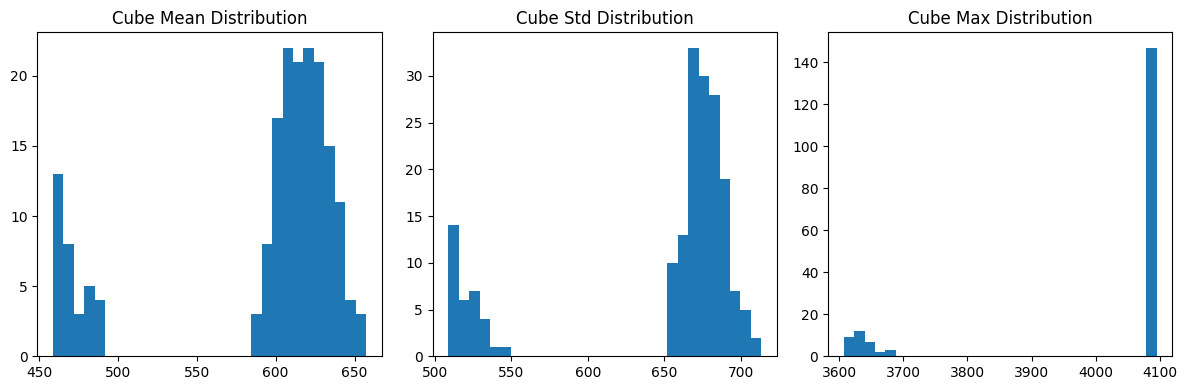

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(cube_stats_df["mean"], bins=30)
plt.title("Cube Mean Distribution")

plt.subplot(1,3,2)
plt.hist(cube_stats_df["std"], bins=30)
plt.title("Cube Std Distribution")

plt.subplot(1,3,3)
plt.hist(cube_stats_df["max"], bins=30)
plt.title("Cube Max Distribution")

plt.tight_layout()
plt.show()


#### Band-wise global statistic

In [ ]:
band_sum = np.zeros(256)
band_sq_sum = np.zeros(256)
total_pixels = 0

for path in cube_paths:
    img = spectral.open_image(path)
    cube = img.load().astype(np.float32)

    band_sum += cube.sum(axis=(0,1))
    band_sq_sum += (cube ** 2).sum(axis=(0,1))
    total_pixels += cube.shape[0] * cube.shape[1]

band_mean = band_sum / total_pixels
band_var = (band_sq_sum / total_pixels) - (band_mean ** 2)
band_std = np.sqrt(band_var)


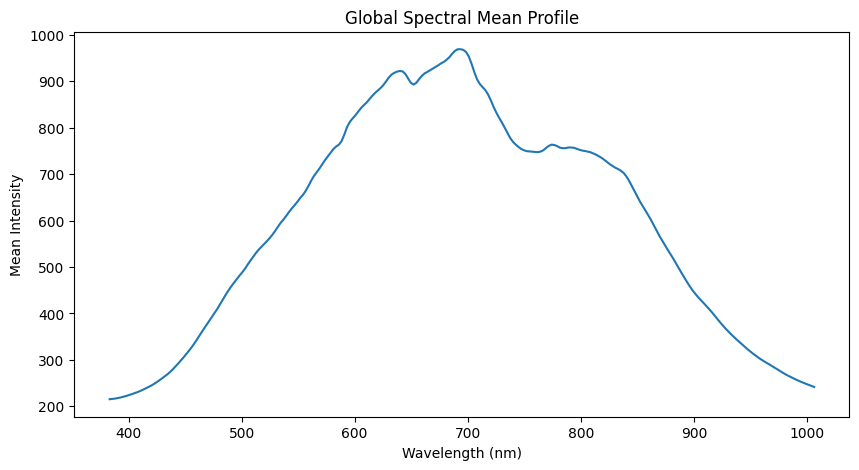

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(wavelengths, band_mean)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Intensity")
plt.title("Global Spectral Mean Profile")
plt.show()

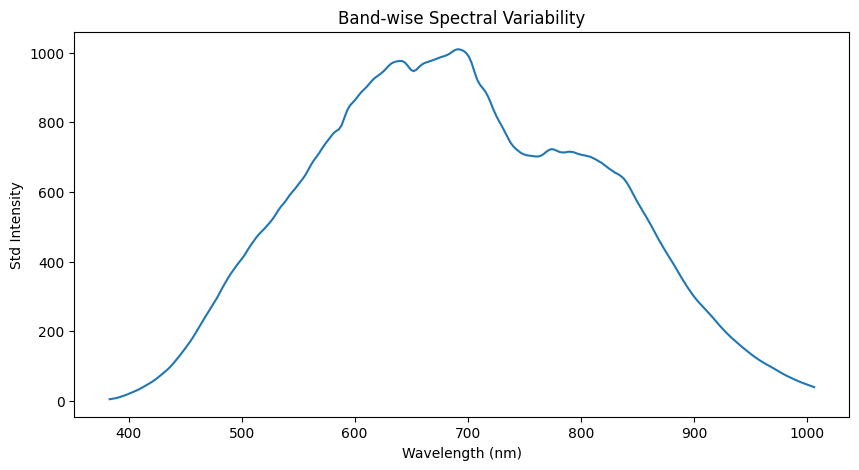

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(wavelengths, band_std)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Std Intensity")
plt.title("Band-wise Spectral Variability")
plt.show()

In [ ]:
# Use one representative cube for speed
img = spectral.open_image(cube_paths[0])
cube = img.load().astype(np.float32)

reshaped = cube.reshape(-1, 256)
corr = np.corrcoef(reshaped.T)


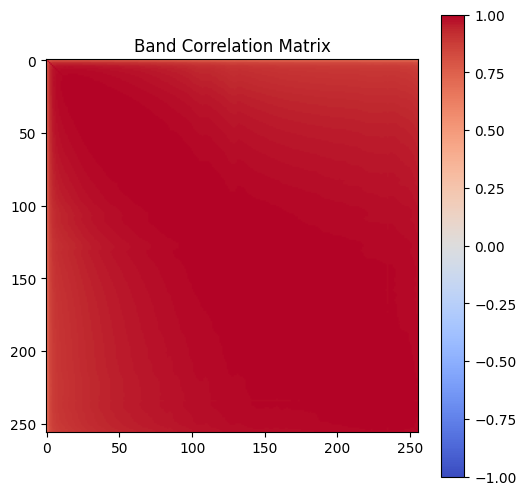

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Band Correlation Matrix")
plt.colorbar()
plt.show()


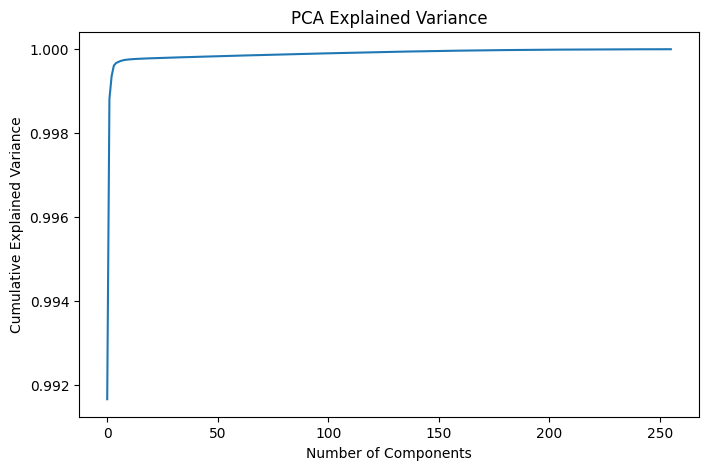

In [ ]:

# Sample subset of pixels to avoid memory overload
sample_pixels = reshaped[np.random.choice(reshaped.shape[0], 50000, replace=False)]

pca = PCA()
pca.fit(sample_pixels)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


#### Dataset Analysis

In [ ]:
records = []

for folder in os.listdir(CONFIG["base_path"]):
    if folder.startswith("Data-VIS"):
        session = folder
        folder_path = os.path.join(CONFIG["base_path"], folder)

        for f in os.listdir(folder_path):
            if f.endswith(".hdr") and f.lower() != "black.hdr":
                name = f.replace(".hdr", "")
                variety = re.sub(r'-\d+$', '', name)
                bundle = int(name.split("-")[-1]) - 1

                records.append({
                    "variety": variety,
                    "bundle": bundle,
                    "session": session,
                    "hsi_path": os.path.join(folder_path, f),
                    "rgb_path": os.path.join(folder_path, name + ".jpg")
                })

df_index = pd.DataFrame(records)
df_index["label"] = pd.factorize(df_index["variety"])[0]

print(df_index.head())
print("Total cubes:", len(df_index))
print("Total classes:", df_index["variety"].nunique())


  variety  bundle                             session  \
0    BC15       0  Data-VIS-20170111-1-room-light-off   
1    BC15       1  Data-VIS-20170111-1-room-light-off   
2   CT286       0  Data-VIS-20170111-1-room-light-off   
3   CT286       1  Data-VIS-20170111-1-room-light-off   
4    CH12       0  Data-VIS-20170111-1-room-light-off   

                                            hsi_path  \
0  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...   
1  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...   
2  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...   
3  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...   
4  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...   

                                            rgb_path  label  
0  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...      0  
1  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...      0  
2  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...      1  
3  /content/drive/MyDrive/rice_hsi/RGB and VIS-NI...      1  
4  /conten

* Sample visualization

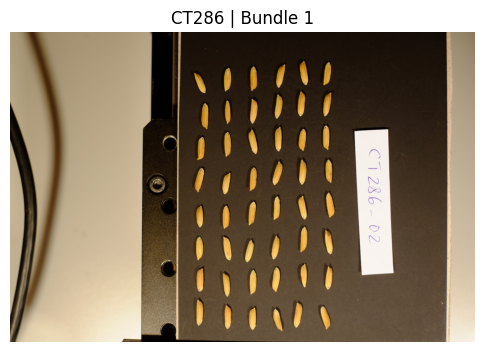

In [ ]:
sample = df_index.iloc[3]

rgb_img = Image.open(sample["rgb_path"])

plt.figure(figsize=(6,6))
plt.imshow(rgb_img)
plt.title(f"{sample['variety']} | Bundle {sample['bundle']}")
plt.axis("off")
plt.show()


In [ ]:
img = spectral.open_image(sample["hsi_path"])
cube = img.load().astype(np.float32)

print("Cube shape:", cube.shape)

Cube shape: (931, 336, 256)


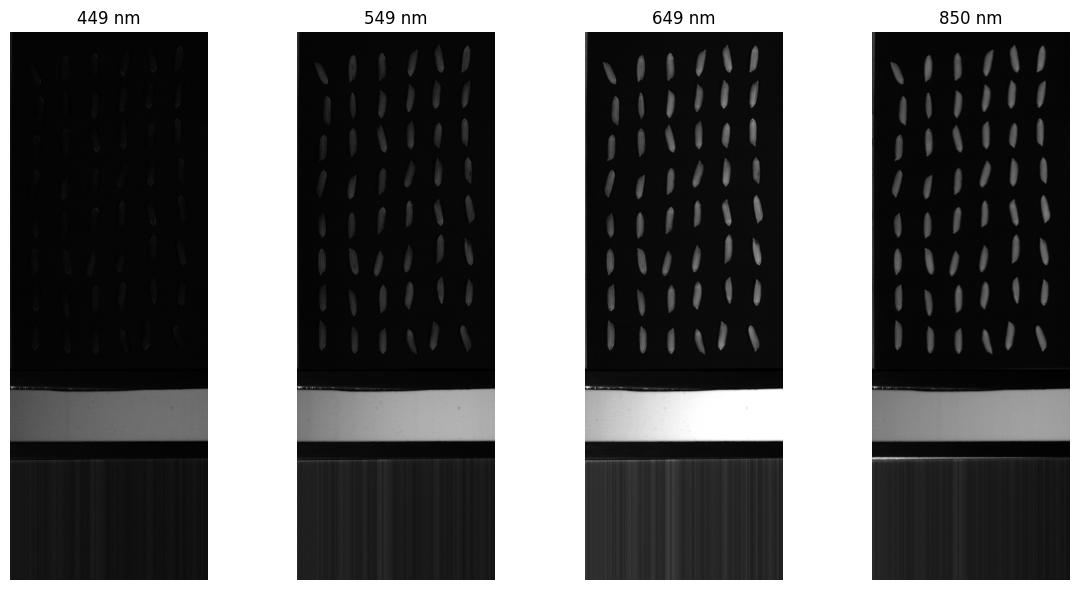

In [ ]:
def find_band(target_wavelength):
    return np.argmin(np.abs(wavelengths - target_wavelength))

bands_to_plot = [450, 550, 650, 850]

plt.figure(figsize=(12,6))

for i, wl in enumerate(bands_to_plot):
    idx = find_band(wl)
    plt.subplot(1,4,i+1)
    plt.imshow(cube[:,:,idx], cmap='gray')
    plt.title(f"{int(wavelengths[idx])} nm")
    plt.axis("off")

plt.tight_layout()
plt.show()


#### Processing workflow

In [ ]:
def load_hsi(path):
    img = spectral.open_image(path)
    cube = img.load().astype(np.float32)
    return cube


def load_dark_reference(session, base_path):
    dark_path = os.path.join(base_path, session, "black.hdr")
    img = spectral.open_image(dark_path)
    dark = img.load().astype(np.float32)
    return dark


def apply_dark_correction(cube, dark):
    dark_mean = dark.mean(axis=0, keepdims=True)

    cube = cube - dark_mean
    cube = np.clip(cube, 0, None)

    return cube

In [ ]:
sample_row = df_index.iloc[112]

hsi_path = sample_row["hsi_path"]
session = sample_row["session"]

print(hsi_path)
print(session)

cube = load_hsi(hsi_path)

print("Cube shape:", cube.shape)
print("Min / Max:", cube.min(), cube.max())


/content/drive/MyDrive/rice_hsi/RGB and VIS-NIR HSI Data for 90 Rice Seed Varieties/Data-VIS-20170113-2-room-light-off/CNC12-01.hdr
Data-VIS-20170113-2-room-light-off
Cube shape: (931, 336, 256)
Min / Max: 192.0 4095.0


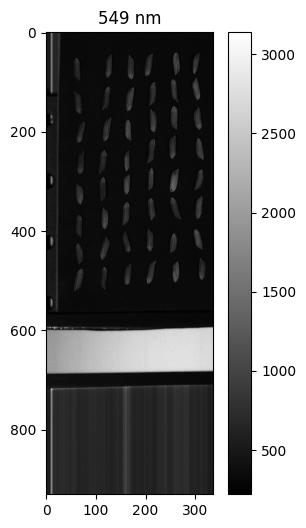

In [ ]:
def show_band(cube, wavelengths, target=550):
    idx = np.argmin(np.abs(wavelengths - target))
    band = cube[:, :, idx]

    plt.figure(figsize=(4,6))
    plt.imshow(band, cmap="gray")
    plt.title(f"{int(wavelengths[idx])} nm")
    plt.colorbar()
    plt.show()

show_band(cube, wavelengths, 550)


After dark correction:
Min / Max: 0.0 3886.9187


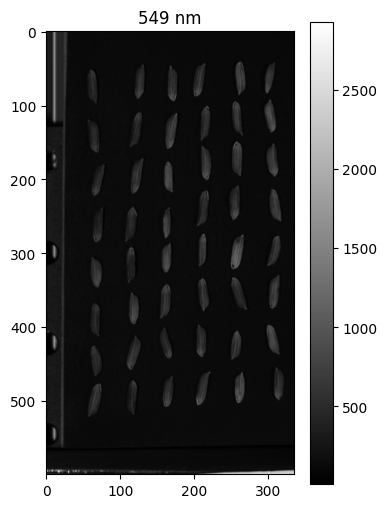

In [ ]:
dark = load_dark_reference(session, CONFIG["base_path"])
cube_corr = apply_dark_correction(cube, dark)

cube_corr = cube_corr[:600, :, :]

print("After dark correction:")
print("Min / Max:", cube_corr.min(), cube_corr.max())

show_band(cube_corr, wavelengths, 550)


In [ ]:
vis_mask = (wavelengths > 450) & (wavelengths < 700)
vis_mean = cube_corr[:, :, vis_mask].mean(axis=2)

print("Vis min/max:", vis_mean.min(), vis_mean.max())


Vis min/max: 22.993942 3042.1443


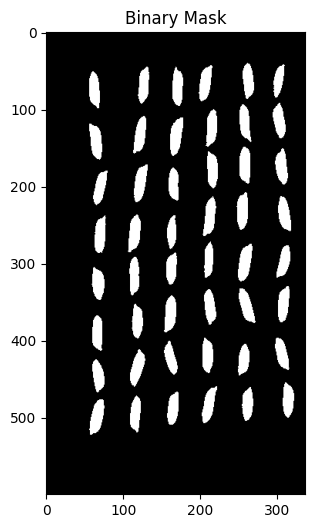

In [ ]:
thresh = threshold_otsu(vis_mean)
binary = vis_mean > (0.4 * thresh)

binary = binary_fill_holes(binary)
binary = clear_border(binary)
binary = remove_small_objects(binary, min_size=150)

plt.figure(figsize=(4,6))
plt.imshow(binary, cmap="gray")
plt.title("Binary Mask")
plt.show()


In [ ]:
labeled = label(binary)
regions = regionprops(labeled)

print("Total raw regions detected:", len(regions))


Total raw regions detected: 48


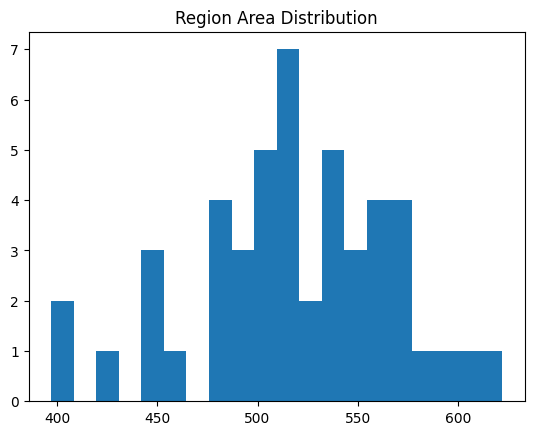

Min area: 397.0
Max area: 622.0


In [ ]:
areas = [r.area for r in regions]

plt.hist(areas, bins=20)
plt.title("Region Area Distribution")
plt.show()

print("Min area:", min(areas))
print("Max area:", max(areas))


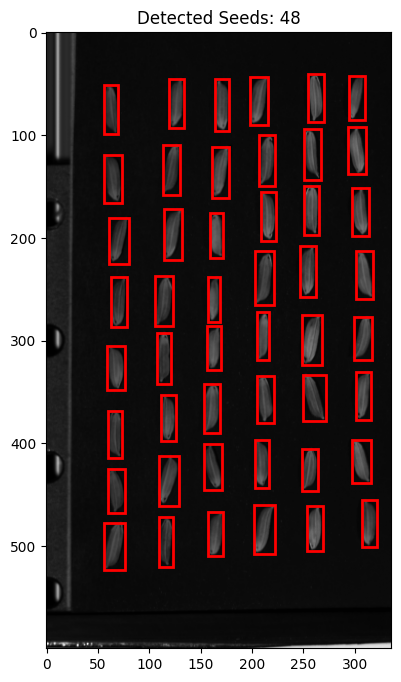

In [ ]:
fig, ax = plt.subplots(figsize=(5,8))
ax.imshow(vis_mean, cmap="gray")

for r in regions:
    minr, minc, maxr, maxc = r.bbox
    rect = patches.Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

plt.title(f"Detected Seeds: {len(regions)}")
plt.show()


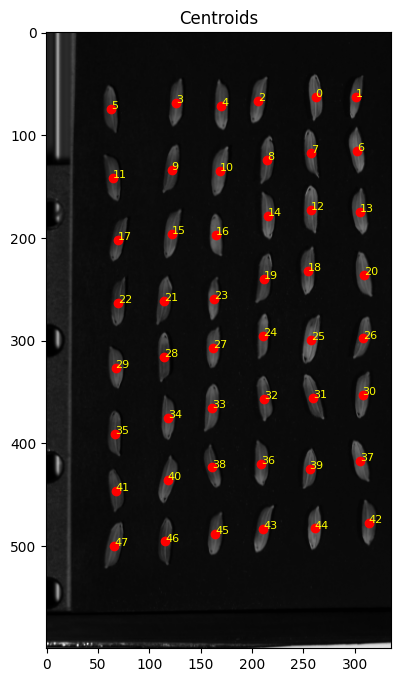

In [ ]:
fig, ax = plt.subplots(figsize=(5,8))
ax.imshow(vis_mean, cmap="gray")

for i, r in enumerate(regions):
    y, x = r.centroid
    ax.plot(x, y, 'ro')
    ax.text(x, y, str(i), color='yellow', fontsize=8)

plt.title("Centroids")
plt.show()

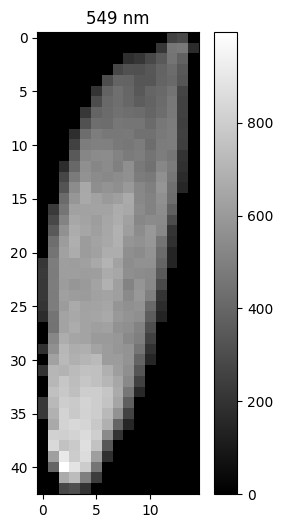

In [ ]:
regions = sorted(
    regions,
    key=lambda r: (r.centroid[0], r.centroid[1])
)

r = regions[0]

minr, minc, maxr, maxc = r.bbox

patch = cube_corr[minr:maxr, minc:maxc, :]
mask = (labeled[minr:maxr, minc:maxc] == r.label)
patch = patch * mask[:, :, None]

show_band(patch, wavelengths, 550)



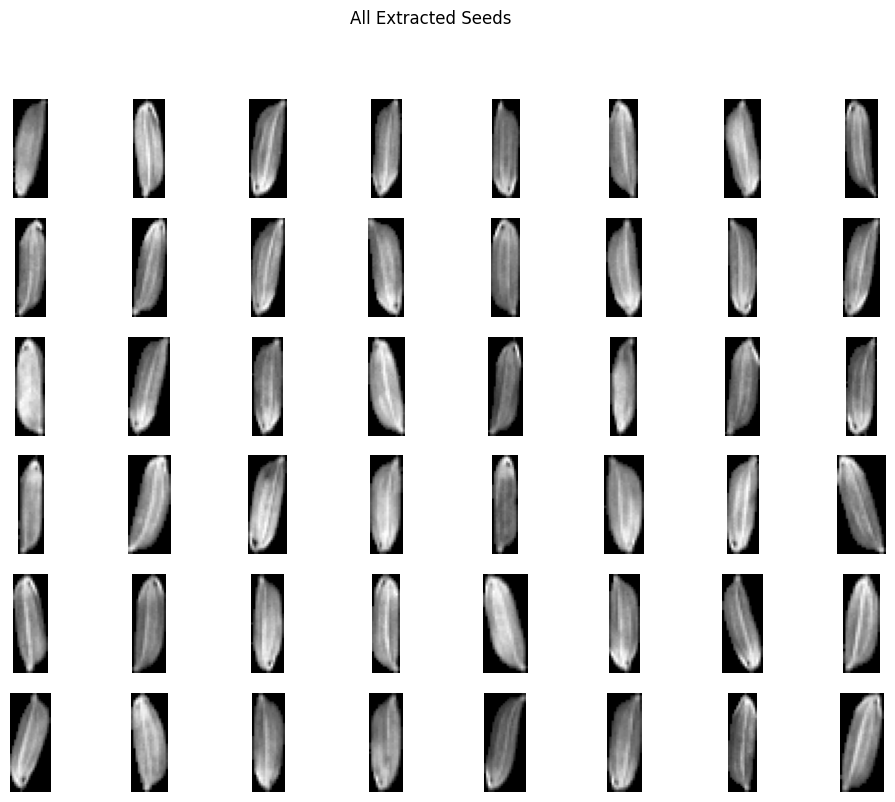

In [ ]:
fig, axes = plt.subplots(6, 8, figsize=(12,9))

for ax, r in zip(axes.flatten(), regions):
    minr, minc, maxr, maxc = r.bbox
    patch = cube_corr[minr:maxr, minc:maxc, :]
    mask = (labeled[minr:maxr, minc:maxc] == r.label)
    patch = patch * mask[:, :, None]

    band = patch[:, :, np.argmin(np.abs(wavelengths - 550))]
    band = (band - band.min()) / (band.max() - band.min() + 1e-6)

    ax.imshow(band, cmap="gray")
    ax.axis("off")

plt.suptitle("All Extracted Seeds")
plt.show()


#### Preprocessing Pipeline

In [ ]:
def preprocess_cube(hsi_path, session, base_path):
    """
    Load cube, apply dark correction,
    and crop non-seed region.
    """
    cube = load_hsi(hsi_path)

    dark = load_dark_reference(session, base_path)
    cube = apply_dark_correction(cube, dark)

    # Remove white calibration + bottom stripes
    cube = cube[:600, :, :]

    return cube

def segment_cube(cube, wavelengths):
    """
    Segment seeds using visible mean + Otsu.
    Returns labeled mask and sorted regions.
    """

    vis_mask = (wavelengths > 450) & (wavelengths < 700)
    vis_mean = cube[:, :, vis_mask].mean(axis=2)

    thresh = threshold_otsu(vis_mean)

    binary = vis_mean > (0.4 * thresh)

    binary = binary_fill_holes(binary)
    binary = clear_border(binary)
    binary = remove_small_objects(binary, min_size=150)

    labeled = label(binary)
    regions = regionprops(labeled)

    regions = [
        r for r in regions
        if 300 < r.area < 800
        and r.eccentricity > 0.6
        and r.solidity > 0.85
    ]

    # Sort spatially (top to bottom, left to right)
    regions = sorted(
        regions,
        key=lambda r: (r.centroid[0], r.centroid[1])
    )

    return labeled, regions


def extract_regions_metadata(regions, labeled, hsi_path, session, label_id):
    """
    Convert regions into lightweight index entries.
    """

    seed_entries = []

    for r in regions:
        seed_entries.append({
            "hsi_path": hsi_path,
            "session": session,
            "label": label_id,
            "bbox": r.bbox,
            "region_label": r.label
        })

    return seed_entries



In [ ]:
def build_seed_index(df_index, base_path, wavelengths):

    seed_index = []

    for i, row in df_index.iterrows():

        hsi_path = row["hsi_path"]
        session = row["session"]
        label_id = row["label"]

        # ---- Step 1: Preprocess cube ----
        cube = preprocess_cube(
            hsi_path,
            session,
            base_path
        )

        # ---- Step 2: Segment cube ----
        labeled, regions = segment_cube(
            cube,
            wavelengths
        )

        # ---- Step 3: Extract metadata ----
        seed_entries = extract_regions_metadata(
            regions,
            labeled,
            hsi_path,
            session,
            label_id
        )

        seed_index.extend(seed_entries)

        print(f"[{i+1}/{len(df_index)}] Seeds detected:", len(regions))

        del cube

    print("Total seed samples:", len(seed_index))

    return seed_index


In [ ]:
seed_index = build_seed_index(
    df_index,
    CONFIG["base_path"],
    wavelengths
)

[1/180] Seeds detected: 48
[2/180] Seeds detected: 48
[3/180] Seeds detected: 48
[4/180] Seeds detected: 48
[5/180] Seeds detected: 48
[6/180] Seeds detected: 48
[7/180] Seeds detected: 48
[8/180] Seeds detected: 48
[9/180] Seeds detected: 48
[10/180] Seeds detected: 45
[11/180] Seeds detected: 46
[12/180] Seeds detected: 48
[13/180] Seeds detected: 48
[14/180] Seeds detected: 48
[15/180] Seeds detected: 48
[16/180] Seeds detected: 48
[17/180] Seeds detected: 48
[18/180] Seeds detected: 48
[19/180] Seeds detected: 48
[20/180] Seeds detected: 48
[21/180] Seeds detected: 48
[22/180] Seeds detected: 48
[23/180] Seeds detected: 48
[24/180] Seeds detected: 48
[25/180] Seeds detected: 48
[26/180] Seeds detected: 47
[27/180] Seeds detected: 48
[28/180] Seeds detected: 48
[29/180] Seeds detected: 48
[30/180] Seeds detected: 48
[31/180] Seeds detected: 48
[32/180] Seeds detected: 48
[33/180] Seeds detected: 48
[34/180] Seeds detected: 48
[35/180] Seeds detected: 48
[36/180] Seeds detected: 48
[

#### Data split

In [ ]:
seed_df = pd.DataFrame(seed_index)

seed_df.head()

,hsi_path,session,label,bbox,region_label
0,/content/drive/MyDrive/rice_hsi/RGB and VIS-NI...,Data-VIS-20170111-1-room-light-off,0,"(35, 173, 81, 189)",1
1,/content/drive/MyDrive/rice_hsi/RGB and VIS-NI...,Data-VIS-20170111-1-room-light-off,0,"(42, 113, 88, 129)",2
2,/content/drive/MyDrive/rice_hsi/RGB and VIS-NI...,Data-VIS-20170111-1-room-light-off,0,"(43, 21, 88, 37)",3
3,/content/drive/MyDrive/rice_hsi/RGB and VIS-NI...,Data-VIS-20170111-1-room-light-off,0,"(46, 284, 91, 298)",4
4,/content/drive/MyDrive/rice_hsi/RGB and VIS-NI...,Data-VIS-20170111-1-room-light-off,0,"(49, 68, 92, 85)",5


In [ ]:
train_df, temp_df = train_test_split(
    seed_df,
    test_size=0.3,
    stratify=seed_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train seeds:", len(train_df))
print("Val seeds:", len(val_df))
print("Test seeds:", len(test_df))


Train seeds: 6036
Val seeds: 1294
Test seeds: 1294


#### Patch processing

In [ ]:
def pad_to_square_centered(patch):
    h, w, c = patch.shape
    size = max(h, w)

    padded = np.zeros((size, size, c), dtype=patch.dtype)

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    padded[y_offset:y_offset+h, x_offset:x_offset+w, :] = patch

    return padded


def resize_patch(patch, size=64):
    bands = patch.shape[2]
    resized = np.zeros((size, size, bands), dtype=np.float32)

    for b in range(bands):
        resized[:, :, b] = cv2.resize(
            patch[:, :, b],
            (size, size),
            interpolation=cv2.INTER_LINEAR
        )

    return resized


def snv_normalize(patch):
    mean = patch.mean()
    std = patch.std() + 1e-6
    return (patch - mean) / std


#### Dataset Class

In [ ]:

# if os.path.exists(CONFIG["patches_dir"]):
#     shutil.rmtree(CONFIG["patches_dir"])

# os.makedirs(CONFIG["patches_dir"], exist_ok=True)

def save_all_patches(seed_df, base_path, wavelengths):

    # Group by cube path
    grouped = seed_df.groupby("hsi_path")

    global_idx = 0

    for hsi_path, group in tqdm(grouped, total=len(grouped), desc="Processing Cubes"):

        session = group.iloc[0]["session"]

        # Load cube ONCE
        cube = preprocess_cube(
            hsi_path,
            session,
            base_path
        )

        labeled, _ = segment_cube(
            cube,
            wavelengths
        )

        # Process all seeds from this cube
        for row in group.itertuples():

            minr, minc, maxr, maxc = row.bbox

            patch = cube[minr:maxr, minc:maxc, :]
            mask = labeled[minr:maxr, minc:maxc] == row.region_label
            patch = patch * mask[:, :, None]

            patch = pad_to_square_centered(patch)
            patch = resize_patch(patch, 64)
            patch = snv_normalize(patch)

            # Save as float16 tensor (half storage, faster IO)
            patch_tensor = torch.from_numpy(
                patch.astype("float16")
            ).permute(2, 0, 1)

            torch.save(
                patch_tensor,
                os.path.join(CONFIG["patches_dir"], f"{global_idx}.pt")
            )

            global_idx += 1

        del cube
        del labeled

    print("Total patches saved:", global_idx)


In [ ]:
# save_all_patches(seed_df, CONFIG["base_path"], wavelengths)

Processing Cubes:   0%|          | 0/180 [00:00<?, ?it/s]

Total patches saved: 8624


In [ ]:
class RiceSeedDataset(Dataset):

    def __init__(
        self,
        dataframe,
        patch_dir,
        augment=False,
        spectral_dropout=False,
        spectral_dropout_prob=0.05
    ):
        self.df = dataframe.reset_index(drop=True)
        self.patch_dir = patch_dir
        self.augment = augment
        self.spectral_dropout = spectral_dropout
        self.spectral_dropout_prob = spectral_dropout_prob

    def __len__(self):
        return len(self.df)

    def _spectral_dropout(self, x):
        if not self.spectral_dropout:
            return x
        mask = torch.rand(x.shape[0]) > self.spectral_dropout_prob
        return x * mask.view(-1,1,1)

    def _spatial_augment(self, x):
        if not self.augment:
            return x
        if random.random() < 0.5:
            x = torch.flip(x, dims=[2])
        if random.random() < 0.5:
            x = torch.flip(x, dims=[1])
        k = random.randint(0, 3)
        x = torch.rot90(x, k, dims=[1,2])
        return x

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # If patch_idx exists use it, otherwise use idx
        patch_idx = row["patch_idx"] if "patch_idx" in row else idx

        patch = torch.load(
            os.path.join(self.patch_dir, f"{patch_idx}.pt"),
            map_location="cpu"
        )

        if patch.dtype == torch.float16:
            patch = patch.float()

        patch = self._spectral_dropout(patch)
        patch = self._spatial_augment(patch)

        label = torch.tensor(row["label"], dtype=torch.long)

        return patch, label


In [ ]:
train_dataset = RiceSeedDataset(train_df, CONFIG["patches_dir"], augment=True, spectral_dropout=True)
val_dataset   = RiceSeedDataset(val_df, CONFIG["patches_dir"])
test_dataset  = RiceSeedDataset(test_df, CONFIG["patches_dir"])

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True
)


#### Visualization

In [ ]:
def find_band(target_wavelength, wavelengths):
    return int(np.argmin(np.abs(wavelengths - target_wavelength)))


def visualize_random_batch(
    loader,
    wavelengths,
    pseudo_rgb_wls=(650, 550, 450),
    max_samples=16,
    max_per_row=8
):
    """
    Stable hyperspectral visualization.
    Automatically adapts figure size.
    """

    # Always use a fresh iterator
    iterator = iter(loader)
    X_batch, y_batch = next(iterator)

    B, C, H, W = X_batch.shape

    n_display = min(B, max_samples)
    indices = np.random.choice(B, n_display, replace=False)

    X_np = X_batch.numpy()

    r_idx = find_band(pseudo_rgb_wls[0], wavelengths)
    g_idx = find_band(pseudo_rgb_wls[1], wavelengths)
    b_idx = find_band(pseudo_rgb_wls[2], wavelengths)

    # Grid calculation
    n_rows = math.ceil(n_display / max_per_row)

    # Adaptive figsize
    fig_width = max_per_row * 2.5
    fig_height = (n_rows * 2.5) + 6

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(n_rows + 2, max_per_row)

    for i, idx in enumerate(indices):

        row = i // max_per_row
        col = i % max_per_row

        ax = fig.add_subplot(gs[row, col])

        sample = X_np[idx]  # (C,H,W)

        rgb = np.stack([
            sample[r_idx],
            sample[g_idx],
            sample[b_idx]
        ], axis=-1)

        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

        ax.imshow(rgb)
        ax.set_title(f"L:{int(y_batch[idx])}", fontsize=8)
        ax.axis("off")

    # Hide empty cells
    for j in range(n_display, n_rows * max_per_row):
        row = j // max_per_row
        col = j % max_per_row
        ax = fig.add_subplot(gs[row, col])
        ax.axis("off")

    ax_spec = fig.add_subplot(gs[n_rows, :])

    for idx in indices:
        spectrum = X_np[idx].mean(axis=(1, 2))
        ax_spec.plot(wavelengths, spectrum, alpha=0.8)

    ax_spec.set_title("Mean Spectral Curves (Selected Samples)")
    ax_spec.set_xlabel("Wavelength (nm)")
    ax_spec.set_ylabel("Intensity")
    ax_spec.grid(alpha=0.3)

    ax_batch = fig.add_subplot(gs[n_rows + 1, :])

    pixels = X_np.reshape(-1, C)
    mean_spectrum = pixels.mean(axis=0)
    std_spectrum = pixels.std(axis=0)

    ax_batch.plot(wavelengths, mean_spectrum, linewidth=2)
    ax_batch.fill_between(
        wavelengths,
        mean_spectrum - std_spectrum,
        mean_spectrum + std_spectrum,
        alpha=0.3
    )

    ax_batch.set_title("Batch Mean Spectrum ± Std")
    ax_batch.set_xlabel("Wavelength (nm)")
    ax_batch.set_ylabel("Intensity")

    plt.tight_layout()
    plt.show()


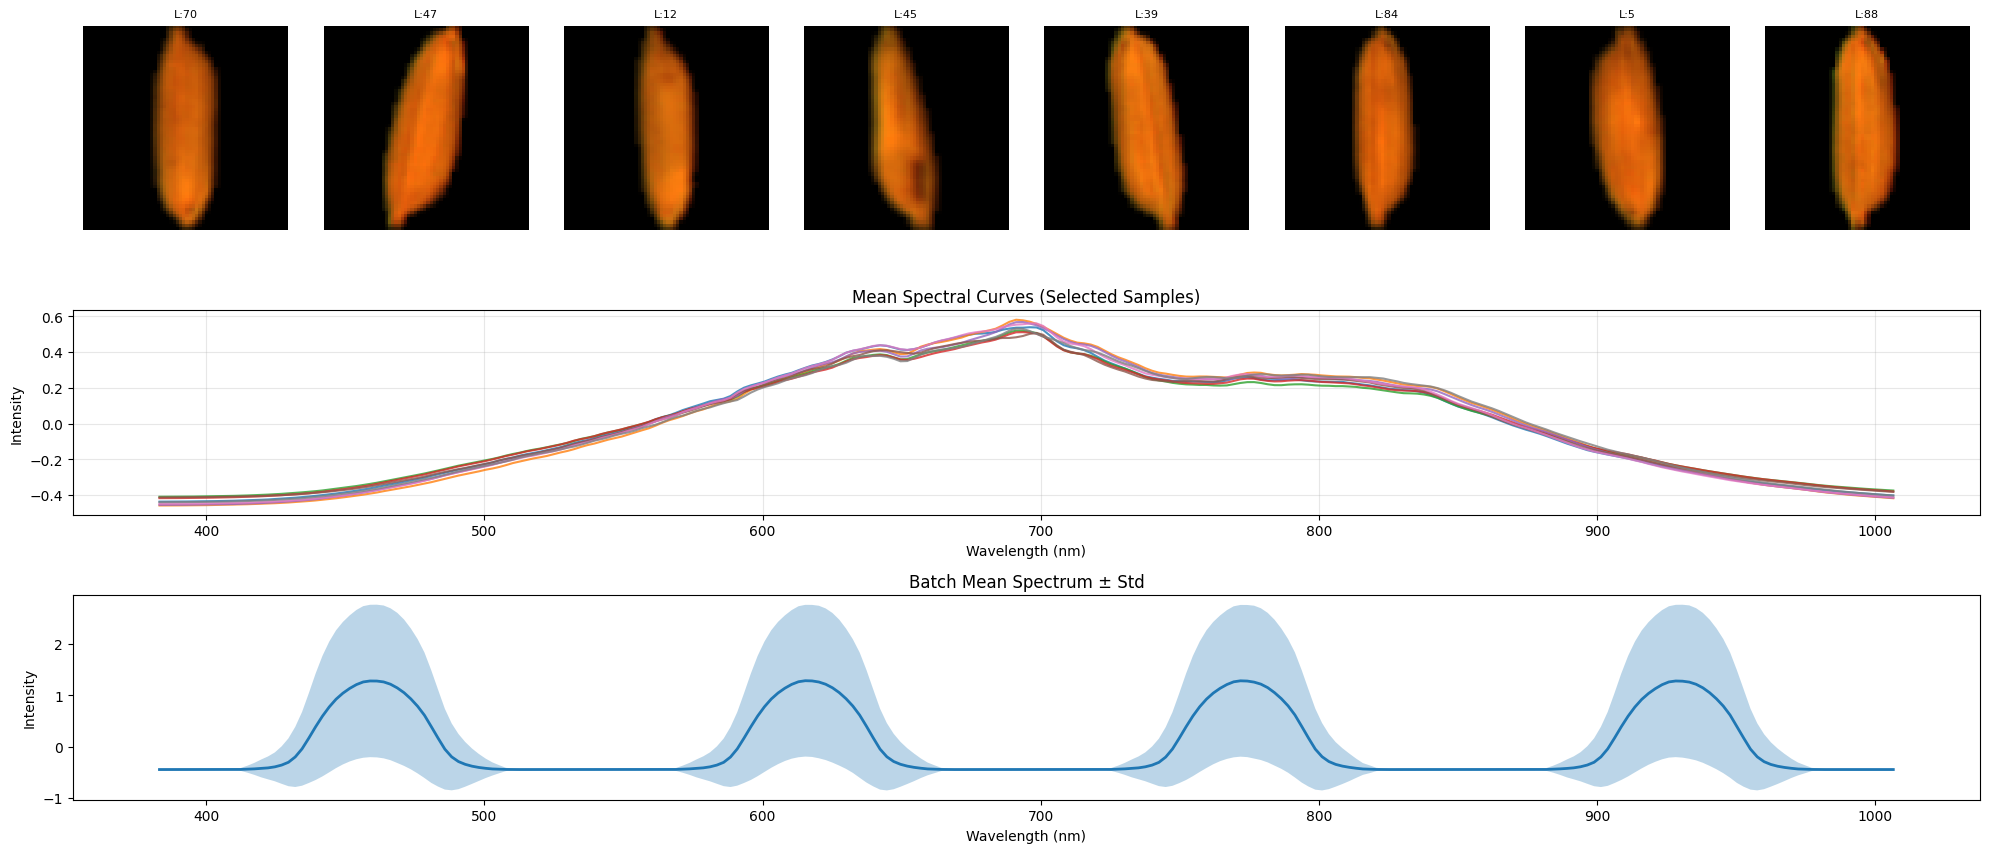

In [ ]:
visualize_random_batch(test_loader, wavelengths, max_samples=8)

### Model Architecture

In [ ]:
class SpectralProjection(nn.Module):
    def __init__(self, in_channels=256, embed_dim=64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.proj(x)

class SpatialBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += residual
        return F.relu(out)

class SpectralAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        B, C, H, W = x.shape

        y = F.adaptive_avg_pool2d(x, 1).view(B, C)

        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(B, C, 1, 1)

        return x * y

class RiceHSINet(nn.Module):
    def __init__(self, num_classes=90, in_channels=256):
        super().__init__()

        self.spectral_proj = SpectralProjection(
            in_channels=in_channels,
            embed_dim=64
        )

        self.stage1 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SpatialBlock(64)
        )

        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SpatialBlock(128)
        )

        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SpatialBlock(256)
        )

        self.attention = SpectralAttention(256)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.spectral_proj(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = self.attention(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RiceHSINet(
    num_classes=90,
    in_channels=256
).to(device)

print("Total parameters:",
      sum(p.numel() for p in model.parameters()) / 1e6,
      "Million")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

scaler = GradScaler()

Total parameters: 2.078586 Million


In [ ]:
def compute_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, f1_macro, f1_weighted, precision, recall


In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    epoch,
    accumulation_steps=1
):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    running_preds = []
    running_labels = []

    batch_bar = tqdm(
        loader,
        desc=f"Epoch {epoch:02d} [Train]",
        leave=False
    )

    optimizer.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(batch_bar):

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)


        with autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logits = model(x)
            loss = criterion(logits, y)
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * x.size(0) * accumulation_steps

        preds = torch.argmax(logits, dim=1)

        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

        running_preds.append(preds.detach().cpu())
        running_labels.append(y.detach().cpu())

        batch_bar.set_postfix(loss=loss.item() * accumulation_steps)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    all_preds = torch.cat(running_preds).numpy()
    all_labels = torch.cat(running_labels).numpy()

    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1_macro, f1_weighted, precision, recall


In [ ]:
def evaluate(
    model,
    loader,
    criterion,
    device,
    epoch,
    phase="Val"
):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    running_preds = []
    running_labels = []

    with torch.no_grad():

        batch_bar = tqdm(
            loader,
            desc=f"Epoch {epoch:02d} [{phase}]",
            leave=False
        )

        for x, y in batch_bar:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)

            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)

            running_preds.append(preds.cpu())
            running_labels.append(y.cpu())

            batch_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    all_preds = torch.cat(running_preds).numpy()
    all_labels = torch.cat(running_labels).numpy()

    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1_macro, f1_weighted, precision, recall


In [ ]:
device

device(type='cuda')

In [ ]:
!nvidia-smi

Mon Feb 16 08:46:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             35W /   70W |     437MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
num_epochs = 30
best_val_f1 = 0
patience = 7
patience_counter = 0

model_path = os.path.join(CONFIG["base_path"], "best_model.pth")

for epoch in range(1, num_epochs + 1):

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        epoch,
        accumulation_steps=1
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device,
        epoch,
        phase="Val"
    )

    scheduler.step()

    print(f"\nEpoch {epoch:02d}")
    print(f"Train | Loss: {train_metrics[0]:.4f} | "
          f"Acc: {train_metrics[1]:.4f} | "
          f"F1(macro): {train_metrics[2]:.4f}")

    print(f"Val   | Loss: {val_metrics[0]:.4f} | "
          f"Acc: {val_metrics[1]:.4f} | "
          f"F1(macro): {val_metrics[2]:.4f}")

    if val_metrics[2] > best_val_f1:
        best_val_f1 = val_metrics[2]
        torch.save(model.state_dict(), model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break


Epoch 01 [Train]:   0%|          | 0/189 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 01 [Val]:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 01
Train | Loss: 4.5081 | Acc: 0.0104 | F1(macro): 0.0051
Val   | Loss: 4.5016 | Acc: 0.0108 | F1(macro): 0.0002


Epoch 02 [Train]:   0%|          | 0/189 [00:00<?, ?it/s]

...

Epoch 11 [Val]:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 11
Train | Loss: 4.4978 | Acc: 0.0133 | F1(macro): 0.0068
Val   | Loss: 4.5039 | Acc: 0.0116 | F1(macro): 0.0011


Epoch 12 [Train]:   0%|          | 0/189 [00:00<?, ?it/s]

Epoch 12 [Val]:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 12
Train | Loss: 4.4958 | Acc: 0.0134 | F1(macro): 0.0056
Val   | Loss: 4.5031 | Acc: 0.0100 | F1(macro): 0.0009
Early stopping triggered.


In [ ]:
# Final model test
test_metrics = evaluate(
    model, test_loader, criterion, device
)

print("\n===== FINAL TEST RESULTS =====")
print(f"Loss: {test_metrics[0]:.4f}")
print(f"Accuracy: {test_metrics[1]:.4f}")
print(f"F1 (macro): {test_metrics[2]:.4f}")
print(f"F1 (weighted): {test_metrics[3]:.4f}")
print(f"Precision: {test_metrics[4]:.4f}")
print(f"Recall: {test_metrics[5]:.4f}")



TypeError: evaluate() missing 1 required positional argument: 'epoch'

In [ ]:
# Best model test
model.load_state_dict(torch.load(model_path))

test_metrics = evaluate(
    model, test_loader, criterion, device
)

print("\n===== FINAL TEST RESULTS =====")
print(f"Loss: {test_metrics[0]:.4f}")
print(f"Accuracy: {test_metrics[1]:.4f}")
print(f"F1 (macro): {test_metrics[2]:.4f}")
print(f"F1 (weighted): {test_metrics[3]:.4f}")
print(f"Precision: {test_metrics[4]:.4f}")
print(f"Recall: {test_metrics[5]:.4f}")

